# Kusto Query Language (KQL)

KQL is a **read-only query language** developed by Microsoft for querying large datasets in near real-time. It's the primary language used in:

- **Azure Data Explorer (ADX)** — Microsoft's big data analytics service
- **Microsoft Sentinel** — cloud-native SIEM for security analytics
- **Azure Monitor / Log Analytics** — infrastructure and application telemetry
- **Microsoft Defender** — threat hunting and security investigations

It's designed specifically for **telemetry, logs, time-series data, and observability** — think billions of rows of machine-generated data queried in seconds.

---

## KQL Syntax: The Pipe Model

KQL uses a **left-to-right pipeline** style. You start with a table and chain operations using the `|` (pipe) operator. Each step transforms the data flowing through it:

```kql
SecurityEvent
| where TimeGenerated > ago(24h)
| where EventID == 4625
| summarize FailedLogins = count() by Account
| order by FailedLogins desc
| take 10
```

Reading this like a sentence: *"From SecurityEvent, filter to the last 24 hours, keep only failed login events, count them per account, sort descending, show the top 10."*

---

## Core KQL Operators

| Operator | Purpose | Example |
|---|---|---|
| `where` | Filter rows | `where Level == "Error"` |
| `project` | Select/rename columns | `project Name, Age, City` |
| `summarize` | Aggregate & group | `summarize count() by Region` |
| `extend` | Add computed columns | `extend Duration = EndTime - StartTime` |
| `order by` | Sort results | `order by Timestamp desc` |
| `take` / `limit` | Limit row count | `take 100` |
| `join` | Join two tables | `T1 \| join T2 on Key` |
| `union` | Combine tables | `union T1, T2` |
| `parse` | Extract from strings | `parse msg with * "user=" User ","` |
| `mv-expand` | Expand arrays | `mv-expand tags` |
| `render` | Visualize results | `render timechart` |

---

## KQL vs SQL — Key Differences

| Dimension | KQL | SQL |
|---|---|---|
| **Style** | Pipeline (left-to-right) | Declarative (clause-based) |
| **Read/Write** | Read-only | Read + Write + DDL |
| **Primary use case** | Logs, telemetry, time-series | Relational/transactional data |
| **Time functions** | First-class (`ago()`, `bin()`, `startofday()`) | Bolted on, varies by dialect |
| **Filtering** | `where` early and often | `WHERE` clause |
| **Aggregation** | `summarize ... by` | `GROUP BY` |
| **Column selection** | `project` | `SELECT` |
| **String parsing** | `parse`, `extract()`, `split()` | Limited, dialect-specific |
| **Schema flexibility** | Dynamic columns, JSON nesting | Strict schema |
| **Visualization** | Built-in `render` operator | None |

### Same query, two languages:

**SQL:**
```sql
SELECT Account, COUNT(*) AS FailedLogins
FROM SecurityEvent
WHERE TimeGenerated > DATEADD(hour, -24, GETUTCDATE())
  AND EventID = 4625
ORDER BY FailedLogins DESC
LIMIT 10;
```

**KQL:**
```kql
SecurityEvent
| where TimeGenerated > ago(24h)
| where EventID == 4625
| summarize FailedLogins = count() by Account
| order by FailedLogins desc
| take 10
```

KQL tends to be more **readable and composable** for analytical/log queries — you can mentally trace each transformation step. SQL's clause ordering (`SELECT` before `WHERE` before `GROUP BY`) can feel counterintuitive since it doesn't match the logical execution order.

---

## When to Use KQL

✅ Security investigations & threat hunting
✅ Application performance monitoring
✅ Infrastructure log analysis
✅ Time-series analytics at scale
✅ Azure-native observability stacks

If you're working in **Microsoft Sentinel, Log Analytics, or Azure Data Explorer**, KQL is the go-to. For traditional relational databases and transactional systems, SQL remains the standard.

# KQL vs SQL: A Comprehensive Tutorial with NYC Taxi Data

This notebook teaches **KQL (Kusto Query Language)** and **SQL** side-by-side using a synthetic NYC Taxi dataset.

KQL runs natively on **Azure Data Explorer / Microsoft Sentinel**. Here we simulate its pipeline syntax using Pandas method-chaining, and execute real SQL via **DuckDB** — an in-process analytical database.

---

##  Table of Contents

1. [Setup & Dependencies](#1)
2. [Dataset Generation](#2)
3. [Language Philosophy](#3)
4. [Basic Filtering](#4)
5. [Column Selection](#5)
6. [Derived / Computed Columns](#6)
7. [Aggregation](#7)
8. [Sorting & Limiting](#8)
9. [String Operations](#9)
10. [Date/Time Operations](#10)
11. [Joins](#11)
12. [Subqueries vs Let Statements](#12)
13. [Window Functions](#13)
14. [NULL Handling](#14)
15. [Complex Multi-Step Analytics](#15)
16. [Performance Tips & Cheat Sheet](#16)


---
<a id='1'></a>
## 1. Setup & Dependencies

In [ ]:
%pip install pandas numpy duckdb matplotlib --quiet

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
from datetime import timedelta

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.2f}".format)

print(" All imports successful")
print(f"   pandas  {pd.__version__}")
print(f"   duckdb  {duckdb.__version__}")


 All imports successful
   pandas  2.3.3
   duckdb  1.5.2


---
<a id='2'></a>
## 2. Dataset Generation

We generate **5,000 synthetic NYC taxi trips** spanning January–February 2024. The schema mirrors the real [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).

| Column | Type | Description |
|--------|------|-------------|
| `trip_id` | int | Unique trip identifier |
| `pickup_datetime` | datetime | Trip start timestamp |
| `dropoff_datetime` | datetime | Trip end timestamp |
| `passenger_count` | int | Number of passengers (has NULLs) |
| `trip_distance` | float | Distance in miles |
| `fare_amount` | float | Base fare ($) |
| `tip_amount` | float | Tip amount (has NULLs) |
| `payment_type` | str | Credit Card / Cash / … |
| `pickup_borough` | str | NYC borough |
| `dropoff_borough` | str | NYC borough |
| `vendor_id` | str | CMT / VTS / DDS |
| `rate_code` | str | Standard / JFK / Newark / … |
| `total_amount` | float | fare + tip + surcharges |
| `trip_duration_min` | float | Duration in minutes |


In [2]:
np.random.seed(42)
N = 5_000

taxi = pd.DataFrame({
    "trip_id":          range(1, N + 1),
    "pickup_datetime":  pd.date_range("2024-01-01", periods=N, freq="10min"),
    "dropoff_datetime": pd.date_range("2024-01-01 00:15:00", periods=N, freq="10min"),
    "passenger_count":  np.random.randint(1, 7, N).astype(float),
    "trip_distance":    np.round(np.random.exponential(3, N), 2),
    "fare_amount":      np.round(np.random.uniform(3, 80, N), 2),
    "tip_amount":       np.round(np.random.uniform(0, 15, N), 2),
    "payment_type":     np.random.choice(
                            ["Credit Card", "Cash", "No Charge", "Dispute"],
                            N, p=[0.60, 0.35, 0.03, 0.02]),
    "pickup_borough":   np.random.choice(
                            ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"],
                            N, p=[0.55, 0.20, 0.15, 0.08, 0.02]),
    "dropoff_borough":  np.random.choice(
                            ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"],
                            N, p=[0.50, 0.22, 0.16, 0.09, 0.03]),
    "vendor_id":        np.random.choice(["CMT", "VTS", "DDS"], N),
    "rate_code":        np.random.choice(
                            ["Standard", "JFK", "Newark", "Nassau", "Negotiated", "Group Ride"],
                            N, p=[0.85, 0.06, 0.03, 0.03, 0.02, 0.01]),
})
taxi["total_amount"]      = taxi["fare_amount"] + taxi["tip_amount"] + np.round(np.random.uniform(0.5, 2, N), 2)
taxi["trip_duration_min"] = np.round(np.random.exponential(15, N) + 3, 1)

# Introduce realistic NULLs
taxi.loc[np.random.choice(N, 50, replace=False), "passenger_count"] = np.nan
taxi.loc[np.random.choice(N, 30, replace=False), "tip_amount"]      = np.nan

# Register with DuckDB
con = duckdb.connect()
con.register("taxi", taxi)

print(f" Dataset: {N:,} rows × {taxi.shape[1]} columns")
print(f"   Date range: {taxi['pickup_datetime'].min().date()} → {taxi['pickup_datetime'].max().date()}")
taxi.head(3)


 Dataset: 5,000 rows × 14 columns
   Date range: 2024-01-01 → 2024-02-04


,trip_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,payment_type,pickup_borough,dropoff_borough,vendor_id,rate_code,total_amount,trip_duration_min
0,1,2024-01-01 00:00:00,2024-01-01 00:15:00,4.00,1.48,8.46,8.24,Credit Card,Brooklyn,Queens,DDS,Standard,17.37,23.10
1,2,2024-01-01 00:10:00,2024-01-01 00:25:00,5.00,2.34,17.58,0.02,Credit Card,Queens,Queens,VTS,Standard,19.47,26.70
2,3,2024-01-01 00:20:00,2024-01-01 00:35:00,3.00,10.33,62.39,4.86,Cash,Bronx,Brooklyn,VTS,Standard,68.60,14.00


---
<a id='3'></a>
## 3.  Language Philosophy

### KQL — Pipeline Model
```
TableName
| where   ...     ← filter rows
| extend  ...     ← add columns
| summarize ...   ← aggregate
| order by ...    ← sort
| take N          ← limit
```
Each `|` passes the **transformed table** to the next operator. You read **top → bottom**, like a recipe. Very natural for exploration.

---

### SQL — Declarative / Set-based Model
```sql
SELECT   ...    -- ← 5th evaluated
FROM     ...    -- ← 1st evaluated
JOIN     ...    -- ← 2nd evaluated
WHERE    ...    -- ← 3rd evaluated
GROUP BY ...    -- ← 4th evaluated
HAVING   ...    -- ← 5th evaluated
ORDER BY ...    -- ← 6th evaluated
LIMIT    N      -- ← 7th evaluated
```
You **describe the result** you want; the engine figures out the execution plan. The written order ≠ execution order (which is why `WHERE` can't reference a `SELECT` alias).

---

> **Key mental model:**  
>  KQL → *"Transform this table step by step"*  
>  SQL → *"Describe the result set I want"*


---
<a id='4'></a>
## 4.  Basic Filtering

### Single condition

In [3]:
# ─────────────────────────────────────────────
# 🔷 KQL
# taxi
# | where fare_amount > 50
# | where payment_type == "Credit Card"
# ─────────────────────────────────────────────
kql = (
    taxi
    [taxi["fare_amount"] > 50]
    .pipe(lambda df: df[df["payment_type"] == "Credit Card"])
)
print(f"KQL result: {len(kql):,} rows")
kql[["trip_id","pickup_borough","fare_amount","payment_type"]].head()


KQL result: 1,111 rows


,trip_id,pickup_borough,fare_amount,payment_type
4,5,Brooklyn,50.56,Credit Card
10,11,Manhattan,57.57,Credit Card
24,25,Brooklyn,69.75,Credit Card
33,34,Manhattan,66.55,Credit Card
35,36,Brooklyn,72.54,Credit Card


In [4]:
# ─────────────────────────────────────────────
#  SQL
# ─────────────────────────────────────────────
sql = """
SELECT *
FROM   taxi
WHERE  fare_amount > 50
  AND  payment_type = 'Credit Card'
"""
result = con.execute(sql).df()
print(f"SQL result: {len(result):,} rows")
result[["trip_id","pickup_borough","fare_amount","payment_type"]].head()


SQL result: 1,111 rows


,trip_id,pickup_borough,fare_amount,payment_type
0,5,Brooklyn,50.56,Credit Card
1,11,Manhattan,57.57,Credit Card
2,25,Brooklyn,69.75,Credit Card
3,34,Manhattan,66.55,Credit Card
4,36,Brooklyn,72.54,Credit Card


### Multiple conditions — `in` and `between`

In [5]:
# 🔷 KQL
# taxi
# | where pickup_borough in ("Manhattan", "Brooklyn")
# | where trip_distance between (1.0 .. 5.0)

kql2 = taxi[
    taxi["pickup_borough"].isin(["Manhattan", "Brooklyn"]) &
    taxi["trip_distance"].between(1.0, 5.0)
]
print(f"KQL — Manhattan/Brooklyn, 1–5 miles: {len(kql2):,} rows")

# 🟧 SQL
sql2 = """
SELECT *
FROM   taxi
WHERE  pickup_borough IN ('Manhattan', 'Brooklyn')
  AND  trip_distance  BETWEEN 1.0 AND 5.0
"""
result2 = con.execute(sql2).df()
print(f"SQL — same filter:                   {len(result2):,} rows")
result2[["trip_id","pickup_borough","trip_distance","fare_amount"]].head()


KQL — Manhattan/Brooklyn, 1–5 miles: 2,019 rows
SQL — same filter:                   2,019 rows


,trip_id,pickup_borough,trip_distance,fare_amount
0,1,Brooklyn,1.48,8.46
1,5,Brooklyn,3.14,50.56
2,7,Manhattan,1.41,5.18
3,8,Manhattan,4.89,66.80
4,9,Manhattan,1.70,63.70


> **Note:** KQL uses `==` for equality; SQL uses `=`. KQL `between` syntax: `col between (low .. high)` (inclusive on both ends, same as SQL `BETWEEN`).


---
<a id='5'></a>
## 5.  Column Selection — `project` / `SELECT`

In [6]:
#  KQL
# taxi | project trip_id, pickup_datetime, pickup_borough,
#                dropoff_borough, fare_amount, tip_amount

COLS = ["trip_id","pickup_datetime","pickup_borough","dropoff_borough","fare_amount","tip_amount"]
kql = taxi[COLS]

#  SQL
sql = "SELECT trip_id, pickup_datetime, pickup_borough, dropoff_borough, fare_amount, tip_amount FROM taxi"
result = con.execute(sql).df()

print("KQL (project):"); display(kql.head(3))
print("SQL (SELECT):"); result.head(3)


KQL (project):


,trip_id,pickup_datetime,pickup_borough,dropoff_borough,fare_amount,tip_amount
0,1,2024-01-01 00:00:00,Brooklyn,Queens,8.46,8.24
1,2,2024-01-01 00:10:00,Queens,Queens,17.58,0.02
2,3,2024-01-01 00:20:00,Bronx,Brooklyn,62.39,4.86


SQL (SELECT):


,trip_id,pickup_datetime,pickup_borough,dropoff_borough,fare_amount,tip_amount
0,1,2024-01-01 00:00:00,Brooklyn,Queens,8.46,8.24
1,2,2024-01-01 00:10:00,Queens,Queens,17.58,0.02
2,3,2024-01-01 00:20:00,Bronx,Brooklyn,62.39,4.86


### Drop columns  `project-away` / `SELECT * EXCLUDE`

In [7]:
#  KQL:  taxi | project-away vendor_id, rate_code
kql_away = taxi.drop(columns=["vendor_id", "rate_code"])
print(f"KQL project-away: {kql_away.columns.tolist()}")

# 🟧 SQL (DuckDB extension):  SELECT * EXCLUDE (vendor_id, rate_code)
sql_excl = "SELECT * EXCLUDE (vendor_id, rate_code) FROM taxi LIMIT 3"
con.execute(sql_excl).df()


KQL project-away: ['trip_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'fare_amount', 'tip_amount', 'payment_type', 'pickup_borough', 'dropoff_borough', 'total_amount', 'trip_duration_min']


,trip_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,payment_type,pickup_borough,dropoff_borough,total_amount,trip_duration_min
0,1,2024-01-01 00:00:00,2024-01-01 00:15:00,4.00,1.48,8.46,8.24,Credit Card,Brooklyn,Queens,17.37,23.10
1,2,2024-01-01 00:10:00,2024-01-01 00:25:00,5.00,2.34,17.58,0.02,Credit Card,Queens,Queens,19.47,26.70
2,3,2024-01-01 00:20:00,2024-01-01 00:35:00,3.00,10.33,62.39,4.86,Cash,Bronx,Brooklyn,68.60,14.00


---
<a id='6'></a>
## 6.  Derived / Computed Columns — `extend` / computed `SELECT`

`extend` **adds** new columns while keeping all originals. SQL computed columns only exist in the `SELECT` output.

In [8]:
#  KQL
# taxi
# | extend tip_pct      = tip_amount / fare_amount * 100,
#          speed_mph    = trip_distance / (trip_duration_min / 60),
#          is_long_trip = trip_distance > 10

kql = taxi.assign(
    tip_pct      = lambda d: (d["tip_amount"] / d["fare_amount"] * 100).round(1),
    speed_mph    = lambda d: (d["trip_distance"] / (d["trip_duration_min"] / 60)).round(1),
    is_long_trip = lambda d: d["trip_distance"] > 10
)[["trip_id","fare_amount","tip_amount","tip_pct","trip_distance","trip_duration_min","speed_mph","is_long_trip"]]

#  SQL
sql = """
SELECT trip_id,
       fare_amount,
       tip_amount,
       ROUND(tip_amount / fare_amount * 100, 1)          AS tip_pct,
       trip_distance,
       trip_duration_min,
       ROUND(trip_distance / (trip_duration_min / 60.0), 1) AS speed_mph,
       trip_distance > 10                                 AS is_long_trip
FROM   taxi
LIMIT  5
"""

print("KQL (extend):"); display(kql.head(5))
print("SQL (computed SELECT):"); con.execute(sql).df()


KQL (extend):


,trip_id,fare_amount,tip_amount,tip_pct,trip_distance,trip_duration_min,speed_mph,is_long_trip
0,1,8.46,8.24,97.40,1.48,23.10,3.80,False
1,2,17.58,0.02,0.10,2.34,26.70,5.30,False
2,3,62.39,4.86,7.80,10.33,14.00,44.30,True
3,4,67.79,3.30,4.90,0.21,18.60,0.70,False
4,5,50.56,14.57,28.80,3.14,38.10,4.90,False


SQL (computed SELECT):


,trip_id,fare_amount,tip_amount,tip_pct,trip_distance,trip_duration_min,speed_mph,is_long_trip
0,1,8.46,8.24,97.40,1.48,23.10,3.80,False
1,2,17.58,0.02,0.10,2.34,26.70,5.30,False
2,3,62.39,4.86,7.80,10.33,14.00,44.30,True
3,4,67.79,3.30,4.90,0.21,18.60,0.70,False
4,5,50.56,14.57,28.80,3.14,38.10,4.90,False


---
<a id='7'></a>
## 7.  Aggregation — `summarize` / `GROUP BY`

### 7a. Simple count

In [ ]:
#  KQL
# taxi | summarize TripCount = count() by pickup_borough | order by TripCount desc
kql = (
    taxi
    .groupby("pickup_borough", as_index=False)
    .agg(TripCount=("trip_id","count"))
    .sort_values("TripCount", ascending=False)
)

# 🟧 SQL
sql = """
SELECT   pickup_borough, COUNT(*) AS TripCount
FROM     taxi
GROUP BY pickup_borough
ORDER BY TripCount DESC
"""
result = con.execute(sql).df()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in [(axes[0], kql, "🔷 KQL — summarize"), (axes[1], result, "🟧 SQL — GROUP BY")]:
    ax.bar(df["pickup_borough"], df["TripCount"], color=["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f"])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Borough"); ax.set_ylabel("Trip Count")
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
kql


### 7b. Multiple aggregates

In [10]:
#  KQL
# taxi
# | summarize TripCount=count(), AvgFare=avg(fare_amount),
#             TotalRevenue=sum(total_amount), AvgTip=avg(tip_amount)
#   by pickup_borough, payment_type
# | order by TotalRevenue desc

kql = (
    taxi
    .groupby(["pickup_borough","payment_type"], as_index=False)
    .agg(
        TripCount    =("trip_id",      "count"),
        AvgFare      =("fare_amount",  "mean"),
        TotalRevenue =("total_amount", "sum"),
        AvgTip       =("tip_amount",   "mean"),
    )
    .round(2)
    .sort_values("TotalRevenue", ascending=False)
)

# 🟧 SQL
sql = """
SELECT   pickup_borough, payment_type,
         COUNT(*)                   AS TripCount,
         ROUND(AVG(fare_amount), 2) AS AvgFare,
         ROUND(SUM(total_amount),2) AS TotalRevenue,
         ROUND(AVG(tip_amount),  2) AS AvgTip
FROM     taxi
GROUP BY pickup_borough, payment_type
ORDER BY TotalRevenue DESC
"""
print(" KQL result:"); display(kql.head(8))
print(" SQL result:"); con.execute(sql).df().head(8)


 KQL result:


,pickup_borough,payment_type,TripCount,AvgFare,TotalRevenue,AvgTip
9,Manhattan,Credit Card,1589,41.27,79628.99,7.60
8,Manhattan,Cash,1044,40.75,51789.09,7.62
5,Brooklyn,Credit Card,606,43.60,31787.28,7.62
13,Queens,Credit Card,409,40.98,20360.37,7.55
4,Brooklyn,Cash,357,40.96,17759.96,7.52
12,Queens,Cash,258,41.38,12905.31,7.44
1,Bronx,Credit Card,237,41.79,11933.88,7.29
0,Bronx,Cash,131,41.67,6684.41,8.13


 SQL result:


,pickup_borough,payment_type,TripCount,AvgFare,TotalRevenue,AvgTip
0,Manhattan,Credit Card,1589,41.27,79628.99,7.60
1,Manhattan,Cash,1044,40.75,51789.09,7.62
2,Brooklyn,Credit Card,606,43.60,31787.28,7.62
3,Queens,Credit Card,409,40.98,20360.37,7.55
4,Brooklyn,Cash,357,40.96,17759.96,7.52
5,Queens,Cash,258,41.38,12905.31,7.44
6,Bronx,Credit Card,237,41.79,11933.88,7.29
7,Bronx,Cash,131,41.67,6684.41,8.13


### 7c. HAVING equivalent — filter after aggregation

In [11]:
# 🔷 KQL — use | where AFTER | summarize (no HAVING keyword)
# taxi
# | summarize TripCount=count(), AvgFare=avg(fare_amount) by pickup_borough
# | where TripCount > 500
# | order by AvgFare desc

kql = (
    taxi
    .groupby("pickup_borough", as_index=False)
    .agg(TripCount=("trip_id","count"), AvgFare=("fare_amount","mean"))
    .query("TripCount > 500")
    .sort_values("AvgFare", ascending=False)
    .round(2)
)

# 🟧 SQL — HAVING clause
sql = """
SELECT   pickup_borough,
         COUNT(*) AS TripCount,
         ROUND(AVG(fare_amount),2) AS AvgFare
FROM     taxi
GROUP BY pickup_borough
HAVING   COUNT(*) > 500
ORDER BY AvgFare DESC
"""
print(" KQL (| where after summarize):"); display(kql)
print(" SQL (HAVING):"); con.execute(sql).df()


 KQL (| where after summarize):


,pickup_borough,TripCount,AvgFare
1,Brooklyn,1024,42.69
3,Queens,704,41.01
2,Manhattan,2790,40.87


 SQL (HAVING):


,pickup_borough,TripCount,AvgFare
0,Brooklyn,1024,42.69
1,Queens,704,41.01
2,Manhattan,2790,40.87


> **Key difference:** KQL has **no `HAVING` keyword**. A `| where` after `| summarize` automatically filters aggregated rows — exactly like `HAVING`.

---
<a id='8'></a>
## 8.  Sorting & Limiting — `order by` + `take` / `ORDER BY LIMIT`

In [12]:
#  KQL
# taxi | order by total_amount desc | take 10
kql = taxi.sort_values("total_amount", ascending=False).head(10)

#  SQL
sql = """
SELECT trip_id, pickup_borough, dropoff_borough, total_amount
FROM   taxi ORDER BY total_amount DESC LIMIT 10
"""
result = con.execute(sql).df()

print(" KQL (order by … take 10):"); display(kql[["trip_id","pickup_borough","dropoff_borough","total_amount"]])
print(" SQL (ORDER BY … LIMIT 10):"); result


 KQL (order by … take 10):


,trip_id,pickup_borough,dropoff_borough,total_amount
4667,4668,Manhattan,Queens,95.73
3415,3416,Manhattan,Manhattan,95.52
3658,3659,Manhattan,Brooklyn,95.43
3500,3501,Manhattan,Manhattan,95.21
204,205,Brooklyn,Manhattan,94.92
3947,3948,Manhattan,Queens,94.79
4138,4139,Manhattan,Brooklyn,94.65
1739,1740,Brooklyn,Manhattan,94.30
1045,1046,Manhattan,Manhattan,94.21
3512,3513,Queens,Brooklyn,94.17


 SQL (ORDER BY … LIMIT 10):


,trip_id,pickup_borough,dropoff_borough,total_amount
0,4668,Manhattan,Queens,95.73
1,3416,Manhattan,Manhattan,95.52
2,3659,Manhattan,Brooklyn,95.43
3,3501,Manhattan,Manhattan,95.21
4,205,Brooklyn,Manhattan,94.92
5,3948,Manhattan,Queens,94.79
6,4139,Manhattan,Brooklyn,94.65
7,1740,Brooklyn,Manhattan,94.30
8,1046,Manhattan,Manhattan,94.21
9,3513,Queens,Brooklyn,94.17


In [ ]:
# KQL shorthand: taxi | top 5 by fare_amount desc
top5 = taxi.nlargest(5, "fare_amount")[["trip_id","fare_amount","pickup_borough"]]
print("KQL: top 5 by fare_amount desc")
top5


---
<a id='9'></a>
## 9.  String Operations

### `contains` / `LIKE '%x%'`

In [14]:
#  KQL:  | where pickup_borough contains "Brook"
kql = taxi[taxi["pickup_borough"].str.contains("Brook", case=False)]

#  SQL:  WHERE pickup_borough LIKE '%Brook%'
sql = "SELECT trip_id, pickup_borough FROM taxi WHERE pickup_borough LIKE '%Brook%'"
result = con.execute(sql).df()

print(f"KQL contains 'Brook': {len(kql):,} rows")
print(f"SQL LIKE '%Brook%':   {len(result):,} rows")


KQL contains 'Brook': 1,024 rows
SQL LIKE '%Brook%':   1,024 rows


### String functions  `toupper`, `substring`, `strcat` / `UPPER`, `LEFT`, `||`

In [ ]:
#  KQL
# taxi
# | extend borough_upper = toupper(pickup_borough),
#          payment_short = substring(payment_type, 0, 4),
#          combined      = strcat(pickup_borough, " → ", dropoff_borough)

kql = taxi.assign(
    borough_upper = lambda d: d["pickup_borough"].str.upper(),
    payment_short = lambda d: d["payment_type"].str[:4],
    combined      = lambda d: d["pickup_borough"] + " → " + d["dropoff_borough"],
)[["trip_id","borough_upper","payment_short","combined"]]

# 🟧 SQL
sql = """
SELECT trip_id,
       UPPER(pickup_borough)                        AS borough_upper,
       LEFT(payment_type, 4)                        AS payment_short,
       pickup_borough || ' → ' || dropoff_borough   AS combined
FROM   taxi LIMIT 5
"""
print(" KQL:"); display(kql.head(5))
print(" SQL:"); con.execute(sql).df()


| KQL | SQL | Purpose |
|-----|-----|---------|
| `toupper(col)` | `UPPER(col)` | Uppercase |
| `tolower(col)` | `LOWER(col)` | Lowercase |
| `strlen(col)` | `LENGTH(col)` | String length |
| `substring(col, 0, 4)` | `LEFT(col, 4)` or `SUBSTRING(col,1,4)` | Substring |
| `strcat(a, b)` | `a \|\| b` or `CONCAT(a,b)` | Concatenate |
| `contains "x"` | `LIKE '%x%'` | Substring match |
| `startswith "x"` | `LIKE 'x%'` | Prefix match |
| `matches regex "p"` | `REGEXP_MATCHES(col,'p')` | Regex match |


---
<a id='10'></a>
## 10.  Date/Time Operations

### Extract date parts

In [15]:
#  KQL
# | extend hour_of_day = hourofday(pickup_datetime),
#          day_of_week = dayofweek(pickup_datetime),
#          month_num   = monthofyear(pickup_datetime)

kql = taxi.assign(
    hour_of_day = lambda d: d["pickup_datetime"].dt.hour,
    day_of_week = lambda d: d["pickup_datetime"].dt.day_name(),
    month_num   = lambda d: d["pickup_datetime"].dt.month,
)[["trip_id","pickup_datetime","hour_of_day","day_of_week","month_num"]]

# 🟧 SQL
sql = """
SELECT trip_id, pickup_datetime,
       EXTRACT(hour  FROM pickup_datetime) AS hour_of_day,
       STRFTIME(pickup_datetime, '%A')      AS day_of_week,
       EXTRACT(month FROM pickup_datetime) AS month_num
FROM   taxi LIMIT 5
"""
print(" KQL:"); display(kql.head(5))
print(" SQL:"); con.execute(sql).df()


 KQL:


,trip_id,pickup_datetime,hour_of_day,day_of_week,month_num
0,1,2024-01-01 00:00:00,0,Monday,1
1,2,2024-01-01 00:10:00,0,Monday,1
2,3,2024-01-01 00:20:00,0,Monday,1
3,4,2024-01-01 00:30:00,0,Monday,1
4,5,2024-01-01 00:40:00,0,Monday,1


 SQL:


,trip_id,pickup_datetime,hour_of_day,day_of_week,month_num
0,1,2024-01-01 00:00:00,0,Monday,1
1,2,2024-01-01 00:10:00,0,Monday,1
2,3,2024-01-01 00:20:00,0,Monday,1
3,4,2024-01-01 00:30:00,0,Monday,1
4,5,2024-01-01 00:40:00,0,Monday,1


### Trips per hour `bin()` / `DATE_TRUNC()`

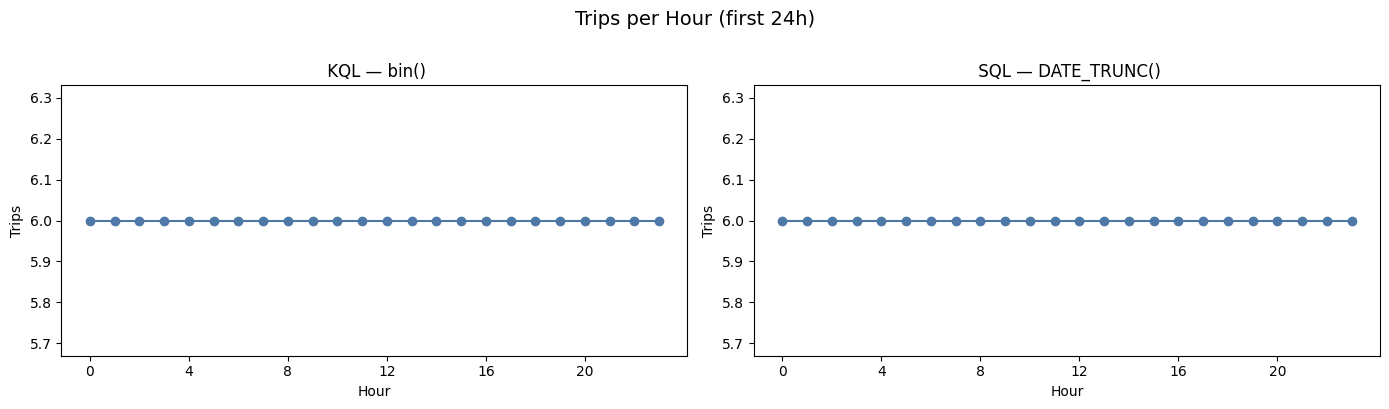

In [19]:
#  KQL
# taxi
# | summarize TripCount=count() by bin(pickup_datetime, 1h)
# | order by pickup_datetime asc | take 24

kql_hourly = (
    taxi
    .assign(hour_bin=lambda d: d["pickup_datetime"].dt.floor("h"))
    .groupby("hour_bin", as_index=False)
    .agg(TripCount=("trip_id","count"))
    .sort_values("hour_bin")
    .head(24)
)

#  SQL
sql = """
SELECT   DATE_TRUNC('hour', pickup_datetime) AS hour_bin,
         COUNT(*) AS TripCount
FROM     taxi
GROUP BY hour_bin
ORDER BY hour_bin
LIMIT    24
"""
sql_hourly = con.execute(sql).df()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title in [(axes[0], kql_hourly, " KQL — bin()"), (axes[1], sql_hourly, " SQL — DATE_TRUNC()")]:
    ax.plot(range(len(df)), df["TripCount"], marker="o", color="#4e79a7")
    ax.set_title(title); ax.set_xlabel("Hour"); ax.set_ylabel("Trips")
    ax.set_xticks(range(0, len(df), 4))
plt.suptitle("Trips per Hour (first 24h)", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


> **KQL's `bin()` tip:** `bin(timestamp, 1h)` truncates to the nearest hour, `bin(timestamp, 1d)` to the nearest day. It is highly optimized in Azure Data Explorer for time-series queries.


---
<a id='11'></a>
## 11.  Joins

First let's create a lookup table:

In [20]:
borough_zones = pd.DataFrame({
    "borough":    ["Manhattan","Brooklyn","Queens","Bronx","Staten Island"],
    "zone_type":  ["Urban Core","Inner Borough","Outer Borough","Outer Borough","Remote"],
    "avg_income": [95_000, 72_000, 68_000, 55_000, 78_000],
})
con.register("borough_zones", borough_zones)
borough_zones


,borough,zone_type,avg_income
0,Manhattan,Urban Core,95000
1,Brooklyn,Inner Borough,72000
2,Queens,Outer Borough,68000
3,Bronx,Outer Borough,55000
4,Staten Island,Remote,78000


### Inner Join

In [21]:
#  KQL
# taxi
# | join kind=inner (borough_zones) on $left.pickup_borough == $right.borough
# | project trip_id, pickup_borough, zone_type, avg_income, fare_amount

kql = (
    taxi.merge(borough_zones, left_on="pickup_borough", right_on="borough", how="inner")
    [["trip_id","pickup_borough","zone_type","avg_income","fare_amount"]]
)

# SQL
sql = """
SELECT t.trip_id, t.pickup_borough,
       bz.zone_type, bz.avg_income, t.fare_amount
FROM   taxi t
INNER JOIN borough_zones bz ON t.pickup_borough = bz.borough
LIMIT 5
"""
print(" KQL (join kind=inner):"); display(kql.head(5))
print("SQL (INNER JOIN):"); con.execute(sql).df()


 KQL (join kind=inner):


,trip_id,pickup_borough,zone_type,avg_income,fare_amount
0,1,Brooklyn,Inner Borough,72000,8.46
1,2,Queens,Outer Borough,68000,17.58
2,3,Bronx,Outer Borough,55000,62.39
3,4,Manhattan,Urban Core,95000,67.79
4,5,Brooklyn,Inner Borough,72000,50.56


SQL (INNER JOIN):


,trip_id,pickup_borough,zone_type,avg_income,fare_amount
0,1,Brooklyn,Inner Borough,72000,8.46
1,2,Queens,Outer Borough,68000,17.58
2,3,Bronx,Outer Borough,55000,62.39
3,4,Manhattan,Urban Core,95000,67.79
4,5,Brooklyn,Inner Borough,72000,50.56


### KQL Join Kinds vs SQL

| KQL `kind=` | SQL equivalent | Returns |
|---|---|---|
| `inner` | `INNER JOIN` | Rows with matches in both tables |
| `leftouter` | `LEFT JOIN` | All left rows + matching right rows |
| `rightouter` | `RIGHT JOIN` | All right rows + matching left rows |
| `fullouter` | `FULL OUTER JOIN` | All rows from both tables |
| `leftanti` | `WHERE col NOT IN (…)` / `NOT EXISTS` | Left rows with **no** match |
| `leftsemi` | `WHERE EXISTS` | Left rows that **have** a match |
| `innerunique` | `INNER JOIN` (deduplicated) | Like inner but deduplicates left side |


In [22]:
# Left Anti Join — trips to boroughs NOT in the lookup (should be none here)
#  KQL:  | join kind=leftanti (borough_zones) on $left.pickup_borough == $right.borough
kql_anti = taxi[~taxi["pickup_borough"].isin(borough_zones["borough"])]
print(f"KQL leftanti: {len(kql_anti)} unmatched trips (expected 0)")

# SQL
sql_anti = """
SELECT t.*
FROM taxi t
WHERE t.pickup_borough NOT IN (SELECT borough FROM borough_zones)
"""
result_anti = con.execute(sql_anti).df()
print(f"SQL NOT IN:   {len(result_anti)} unmatched trips")


KQL leftanti: 0 unmatched trips (expected 0)
SQL NOT IN:   0 unmatched trips


---
<a id='12'></a>
## 12. Subqueries vs `let` Statements

KQL's `let` binds a scalar value or a sub-table to a name. SQL's closest equivalent is a **CTE** (`WITH` clause).

In [24]:
#  KQL
# let high_fare_threshold = 60.0;
# let manhattan_trips =
#     taxi
#     | where pickup_borough == "Manhattan"
#     | where fare_amount > high_fare_threshold;
# manhattan_trips
# | summarize Count=count(), AvgFare=avg(fare_amount) by dropoff_borough
# | order by Count desc

high_fare_threshold = 60.0
manhattan_trips = taxi[
    (taxi["pickup_borough"] == "Manhattan") &
    (taxi["fare_amount"] > high_fare_threshold)
]
kql = (
    manhattan_trips
    .groupby("dropoff_borough", as_index=False)
    .agg(Count=("trip_id","count"), AvgFare=("fare_amount","mean"))
    .round(2)
    .sort_values("Count", ascending=False)
)

#  SQL — CTE
sql = """
WITH manhattan_trips AS (
    SELECT *
    FROM   taxi
    WHERE  pickup_borough = 'Manhattan'
      AND  fare_amount > 60.0
)
SELECT   dropoff_borough,
         COUNT(*) AS Count,
         ROUND(AVG(fare_amount),2) AS AvgFare
FROM     manhattan_trips
GROUP BY dropoff_borough
ORDER BY Count DESC
"""
print("KQL (let):"); display(kql)
print("SQL (CTE):"); con.execute(sql).df()


KQL (let):


,dropoff_borough,Count,AvgFare
2,Manhattan,354,70.01
1,Brooklyn,151,70.59
3,Queens,113,69.92
0,Bronx,53,71.66
4,Staten Island,15,69.77


SQL (CTE):


,dropoff_borough,Count,AvgFare
0,Manhattan,354,70.01
1,Brooklyn,151,70.59
2,Queens,113,69.92
3,Bronx,53,71.66
4,Staten Island,15,69.77


> **Pro tip:** Multiple `let` statements (KQL) or chained CTEs (SQL) allow you to build complex logic step by step, keeping each transformation readable and testable in isolation.

---
<a id='13'></a>
## 13.  Window Functions

Window functions compute values **across related rows** without collapsing them — unlike `GROUP BY` which reduces rows to one per group.

### Rank trips by fare within each borough

In [25]:
# KQL
# taxi
# | sort by pickup_borough asc, fare_amount desc
# | extend rank_in_borough = row_rank()
# | where rank_in_borough <= 3

kql = (
    taxi
    .sort_values(["pickup_borough","fare_amount"], ascending=[True, False])
    .assign(rank_in_borough=lambda d: d.groupby("pickup_borough")["fare_amount"]
            .rank(method="first", ascending=False).astype(int))
    .query("rank_in_borough <= 3")
    [["trip_id","pickup_borough","fare_amount","rank_in_borough"]]
)

# 🟧SQL
sql = """
SELECT trip_id, pickup_borough, fare_amount,
       RANK() OVER (PARTITION BY pickup_borough ORDER BY fare_amount DESC) AS rank_in_borough
FROM   taxi
QUALIFY rank_in_borough <= 3
ORDER BY pickup_borough, rank_in_borough
"""
print(" KQL (row_rank):"); display(kql.head(12))
print(" SQL (RANK() OVER):"); con.execute(sql).df().head(12)


 KQL (row_rank):


,trip_id,pickup_borough,fare_amount,rank_in_borough
3207,3208,Bronx,79.95,1
3822,3823,Bronx,79.66,2
3096,3097,Bronx,79.22,3
3365,3366,Brooklyn,79.90,1
1099,1100,Brooklyn,79.89,2
4620,4621,Brooklyn,79.70,3
2657,2658,Manhattan,79.97,1
1635,1636,Manhattan,79.96,2
4760,4761,Manhattan,79.91,3
328,329,Queens,79.69,1


 SQL (RANK() OVER):


,trip_id,pickup_borough,fare_amount,rank_in_borough
0,3208,Bronx,79.95,1
1,3823,Bronx,79.66,2
2,3097,Bronx,79.22,3
3,3366,Brooklyn,79.90,1
4,1100,Brooklyn,79.89,2
5,4621,Brooklyn,79.70,3
6,2658,Manhattan,79.97,1
7,1636,Manhattan,79.96,2
8,4761,Manhattan,79.91,3
9,329,Queens,79.69,1


### Running total & moving average

Running total revenue:


,trip_id,pickup_datetime,total_amount,running_total
0,1,2024-01-01 00:00:00,17.37,17.37
1,2,2024-01-01 00:10:00,19.47,36.84
2,3,2024-01-01 00:20:00,68.60,105.44
3,4,2024-01-01 00:30:00,72.91,178.35
4,5,2024-01-01 00:40:00,67.05,245.40
5,6,2024-01-01 00:50:00,65.32,310.72
6,7,2024-01-01 01:00:00,11.52,322.24
7,8,2024-01-01 01:10:00,69.65,391.89
8,9,2024-01-01 01:20:00,72.65,464.54
9,10,2024-01-01 01:30:00,27.20,491.74


5-trip moving average fare:


,trip_id,pickup_datetime,fare_amount,moving_avg_5
0,1,2024-01-01 00:00:00,8.46,8.46
1,2,2024-01-01 00:10:00,17.58,13.02
2,3,2024-01-01 00:20:00,62.39,29.48
3,4,2024-01-01 00:30:00,67.79,39.06
4,5,2024-01-01 00:40:00,50.56,41.36
5,6,2024-01-01 00:50:00,52.62,50.19
6,7,2024-01-01 01:00:00,5.18,47.71
7,8,2024-01-01 01:10:00,66.80,48.59
8,9,2024-01-01 01:20:00,63.70,47.77
9,10,2024-01-01 01:30:00,22.95,42.25


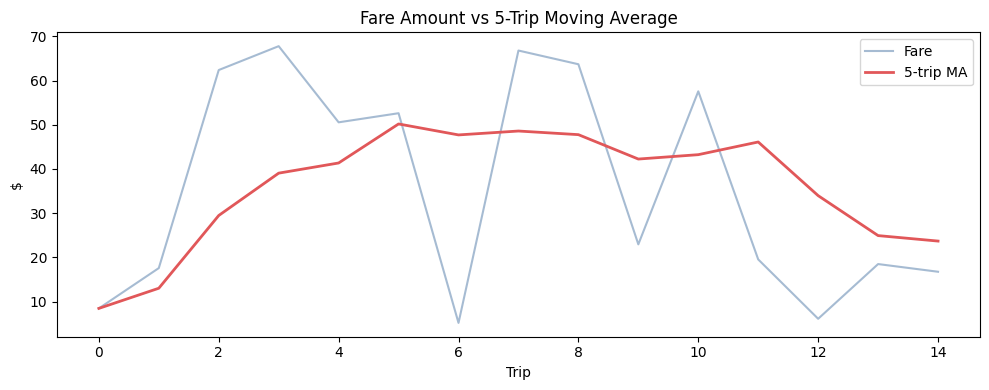

In [26]:
# SQL — Running cumulative revenue
sql_running = """
SELECT trip_id, pickup_datetime, total_amount,
       ROUND(SUM(total_amount) OVER (
           ORDER BY pickup_datetime
           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
       ), 2) AS running_total
FROM   taxi
ORDER  BY pickup_datetime
LIMIT  10
"""

# SQL — 5-trip moving average
sql_ma = """
SELECT trip_id, pickup_datetime, fare_amount,
       ROUND(AVG(fare_amount) OVER (
           ORDER BY pickup_datetime
           ROWS BETWEEN 4 PRECEDING AND CURRENT ROW
       ), 2) AS moving_avg_5
FROM   taxi
ORDER  BY pickup_datetime
LIMIT  15
"""

print("Running total revenue:"); display(con.execute(sql_running).df())
print("5-trip moving average fare:")
df_ma = con.execute(sql_ma).df()
display(df_ma)

# Plot the moving average
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_ma.index, df_ma["fare_amount"],   alpha=0.5, label="Fare", color="#4e79a7")
ax.plot(df_ma.index, df_ma["moving_avg_5"], linewidth=2, label="5-trip MA", color="#e15759")
ax.set_title("Fare Amount vs 5-Trip Moving Average"); ax.set_xlabel("Trip"); ax.set_ylabel("$")
ax.legend(); plt.tight_layout(); plt.show()


| KQL | SQL OVER() | Purpose |
|-----|-----------|---------|
| `row_rank()` | `RANK() OVER (PARTITION BY … ORDER BY …)` | Rank within group |
| `row_number()` | `ROW_NUMBER() OVER (…)` | Sequential row number |
| `row_cumsum(col)` | `SUM(col) OVER (ORDER BY … ROWS UNBOUNDED PRECEDING)` | Cumulative sum |
| `prev(col)` | `LAG(col) OVER (ORDER BY …)` | Previous row value |
| `next(col)` | `LEAD(col) OVER (ORDER BY …)` | Next row value |


---
<a id='14'></a>
## 14. NULL Handling

In [28]:
print("Null counts in dataset:")
print(taxi[["passenger_count","tip_amount"]].isnull().sum().to_string())


Null counts in dataset:
passenger_count    50
tip_amount         30


In [27]:
# ── Filter out NULLs ─────────────────────────────────────────────────────
# 🔷 KQL:  | where isnotnull(passenger_count)
kql_nn = taxi[taxi["passenger_count"].notna()]
print(f"After removing NULL passenger_count: {len(kql_nn):,} rows")

#  SQL
r = con.execute("SELECT COUNT(*) FROM taxi WHERE passenger_count IS NOT NULL").fetchone()[0]
print(f"SQL IS NOT NULL:                     {r:,} rows")

# ── Fill NULLs with coalesce ──────────────────────────────────────────────
# KQL:  | extend tip_filled = coalesce(tip_amount, 0.0)
# SQL:  COALESCE(tip_amount, 0.0)
sql = "SELECT trip_id, tip_amount, COALESCE(tip_amount, 0.0) AS tip_filled FROM taxi WHERE tip_amount IS NULL LIMIT 5"
print("\nNULL tips filled with 0:")
con.execute(sql).df()


After removing NULL passenger_count: 4,950 rows
SQL IS NOT NULL:                     4,950 rows

NULL tips filled with 0:


,trip_id,tip_amount,tip_filled
0,297,NaN,0.00
1,609,NaN,0.00
2,857,NaN,0.00
3,971,NaN,0.00
4,1044,NaN,0.00


In [29]:
# ── Count NULLs per column ────────────────────────────────────────────────
#  KQL:
# taxi | summarize
#     null_passengers = countif(isnull(passenger_count)),
#     null_tips       = countif(isnull(tip_amount))

print("KQL countif(isnull(...)):")
print(f"  null_passengers: {taxi['passenger_count'].isna().sum()}")
print(f"  null_tips:       {taxi['tip_amount'].isna().sum()}")

#  SQL
sql = """
SELECT
    SUM(CASE WHEN passenger_count IS NULL THEN 1 ELSE 0 END) AS null_passengers,
    SUM(CASE WHEN tip_amount      IS NULL THEN 1 ELSE 0 END) AS null_tips
FROM taxi
"""
print("\nSQL CASE WHEN IS NULL:")
con.execute(sql).df()


KQL countif(isnull(...)):
  null_passengers: 50
  null_tips:       30

SQL CASE WHEN IS NULL:


,null_passengers,null_tips
0,50.00,30.00


---
<a id='15'></a>
## 15. Complex Multi-Step Analytics

### Analysis 1: Peak-hour profitability by borough

> Which borough + hour combination gives the highest average revenue for credit card trips over 1 mile?

In [30]:
#  KQL
# taxi
# | where payment_type == "Credit Card"
# | where trip_distance > 1.0
# | extend hour_of_day = hourofday(pickup_datetime)
# | summarize TripCount=count(), AvgRevenue=avg(total_amount),
#             AvgTip=avg(tip_amount), AvgDistance=avg(trip_distance)
#   by pickup_borough, hour_of_day
# | where TripCount > 10
# | extend RevenuePerMile = round(AvgRevenue / AvgDistance, 2)
# | top 10 by AvgRevenue desc

kql = (
    taxi
    .query("payment_type == 'Credit Card' and trip_distance > 1.0")
    .assign(hour_of_day=lambda d: d["pickup_datetime"].dt.hour)
    .groupby(["pickup_borough","hour_of_day"], as_index=False)
    .agg(TripCount=("trip_id","count"), AvgRevenue=("total_amount","mean"),
         AvgTip=("tip_amount","mean"), AvgDistance=("trip_distance","mean"))
    .query("TripCount > 10")
    .assign(RevenuePerMile=lambda d: (d["AvgRevenue"] / d["AvgDistance"]).round(2))
    .sort_values("AvgRevenue", ascending=False)
    .head(10).round(2)
)

#  SQL — same logic with CTEs
sql = """
WITH filtered AS (
    SELECT *, EXTRACT(hour FROM pickup_datetime) AS hour_of_day
    FROM   taxi
    WHERE  payment_type = 'Credit Card' AND trip_distance > 1.0
),
agg AS (
    SELECT   pickup_borough, hour_of_day,
             COUNT(*)                    AS TripCount,
             ROUND(AVG(total_amount), 2) AS AvgRevenue,
             ROUND(AVG(tip_amount),   2) AS AvgTip,
             ROUND(AVG(trip_distance),2) AS AvgDistance
    FROM     filtered
    GROUP BY pickup_borough, hour_of_day
    HAVING   COUNT(*) > 10
)
SELECT *, ROUND(AvgRevenue / AvgDistance, 2) AS RevenuePerMile
FROM   agg
ORDER  BY AvgRevenue DESC
LIMIT  10
"""
print(" KQL top 10 peak-hour profitability:"); display(kql)
print(" SQL top 10:"); con.execute(sql).df()


 KQL top 10 peak-hour profitability:


,pickup_borough,hour_of_day,TripCount,AvgRevenue,AvgTip,AvgDistance,RevenuePerMile
40,Brooklyn,16,17,69.50,8.84,3.77,18.42
47,Brooklyn,23,16,68.29,7.85,3.12,21.91
35,Brooklyn,11,16,66.19,8.54,2.97,22.29
85,Queens,13,11,63.08,9.31,5.51,11.44
24,Brooklyn,0,20,59.25,9.55,3.23,18.33
92,Queens,20,14,58.41,6.81,4.19,13.95
45,Brooklyn,21,13,56.83,9.03,4.09,13.90
37,Brooklyn,13,16,56.07,6.59,4.66,12.02
80,Queens,8,18,55.85,6.24,4.78,11.69
82,Queens,10,14,55.41,8.06,3.14,17.64


 SQL top 10:


,pickup_borough,hour_of_day,TripCount,AvgRevenue,AvgTip,AvgDistance,RevenuePerMile
0,Brooklyn,16,17,69.50,8.84,3.77,18.44
1,Brooklyn,23,16,68.29,7.85,3.12,21.89
2,Brooklyn,11,16,66.19,8.54,2.97,22.29
3,Queens,13,11,63.08,9.31,5.51,11.45
4,Brooklyn,0,20,59.25,9.55,3.23,18.34
5,Queens,20,14,58.41,6.81,4.19,13.94
6,Brooklyn,21,13,56.83,9.03,4.09,13.89
7,Brooklyn,13,16,56.07,6.59,4.66,12.03
8,Queens,8,18,55.85,6.25,4.78,11.68
9,Queens,10,14,55.41,8.06,3.14,17.65


### Analysis 2: Cross-borough flow matrix

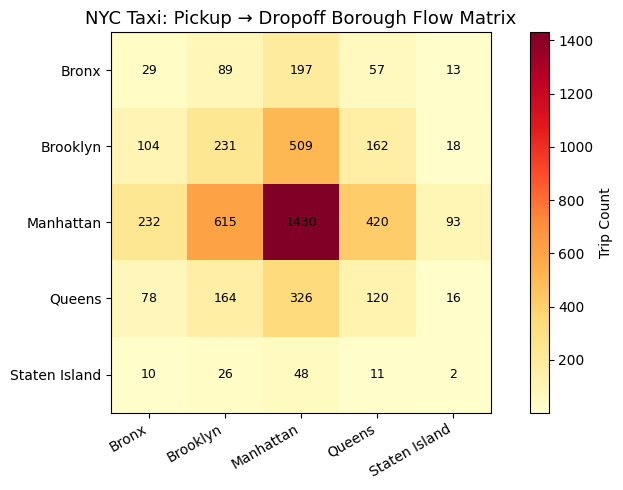

In [31]:
sql_matrix = """
SELECT   pickup_borough, dropoff_borough,
         COUNT(*) AS trip_count,
         ROUND(AVG(fare_amount), 2)  AS avg_fare,
         ROUND(AVG(trip_distance),2) AS avg_dist
FROM     taxi
GROUP BY pickup_borough, dropoff_borough
ORDER BY trip_count DESC
"""
matrix_df = con.execute(sql_matrix).df()
pivot = matrix_df.pivot_table(
    index="pickup_borough", columns="dropoff_borough",
    values="trip_count", fill_value=0
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="YlOrRd")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, int(pivot.values[i,j]), ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Trip Count")
ax.set_title("NYC Taxi: Pickup → Dropoff Borough Flow Matrix", fontsize=13)
plt.tight_layout(); plt.show()


---
<a id='16'></a>
## 16.  Performance Tips & Cheat Sheet

### KQL Performance Tips

| Tip | Bad  | Good  |
|-----|--------|---------|
| **Filter early** | `…\| extend x=…\| summarize…\| where borough=="Manhattan"` | `\| where borough=="Manhattan"\| extend x=…\| summarize…` |
| **has vs contains** | `\| where col contains "word"` (scan) | `\| where col has "word"` (index) |
| **Avoid regex when possible** | `matches regex "^NYC.*"` | `startswith "NYC"` |
| **project early** | join on full-width table | `\| project needed_cols` before join |
| **summarize before join** | join large table then aggregate | aggregate first, then join |

---

### SQL Performance Tips

| Tip | Notes |
|-----|-------|
| **Filter in WHERE** | Push filters down before joins |
| **Use CTEs** | Same performance as subqueries, far more readable |
| **EXPLAIN** | `EXPLAIN SELECT …` to view the query plan |
| **LIMIT during exploration** | Avoid full scans while iterating |
| **Columnar DBs (DuckDB)** | Aggregations on single columns are very fast |

---

###  Full KQL ↔ SQL Cheat Sheet


In [32]:
cheat = pd.DataFrame({
    "KQL": [
        "TableName",
        "| where col == val",
        "| where col != val",
        "| project col1, col2",
        "| project-away col1",
        "| extend newcol = expr",
        "| summarize agg() by col",
        "| where (after summarize)",
        "| order by col desc",
        "| take N",
        "| top N by col desc",
        "| join kind=inner (T2) on col",
        "| join kind=leftouter (T2) on c",
        "| join kind=leftanti (T2) on c",
        "| join kind=leftsemi (T2) on c",
        "| union (T2)",
        "| distinct col",
        "let x = val;",
        "| count",
        "countif(condition)",
        "isnotnull(col)",
        "isnull(col)",
        "coalesce(col, default)",
        "bin(col, 1h)",
        "ago(7d)",
        "hourofday(dt)",
        "strcat(a, b)",
        "toupper(col) / tolower(col)",
        "strlen(col)",
        "contains 'x'",
        "startswith 'x'",
        "matches regex 'p'",
        "row_rank()",
        "row_number()",
        "prev(col)",
        "next(col)",
        "row_cumsum(col)",
    ],
    "SQL": [
        "FROM TableName",
        "WHERE col = val",
        "WHERE col <> val",
        "SELECT col1, col2",
        "SELECT * EXCLUDE (col1)  [DuckDB]",
        "SELECT *, expr AS newcol",
        "GROUP BY col … (aggregates)",
        "HAVING",
        "ORDER BY col DESC",
        "LIMIT N",
        "ORDER BY col DESC LIMIT N",
        "INNER JOIN T2 ON col",
        "LEFT JOIN T2 ON c",
        "WHERE col NOT IN (SELECT …) / NOT EXISTS",
        "WHERE EXISTS (SELECT …)",
        "UNION ALL",
        "SELECT DISTINCT col",
        "WITH x AS (…) or variable",
        "SELECT COUNT(*)",
        "SUM(CASE WHEN cond THEN 1 END)",
        "col IS NOT NULL",
        "col IS NULL",
        "COALESCE(col, default)",
        "DATE_TRUNC('hour', col)",
        "NOW() - INTERVAL '7 days'",
        "EXTRACT(HOUR FROM dt)",
        "a || b  or  CONCAT(a, b)",
        "UPPER(col) / LOWER(col)",
        "LENGTH(col)",
        "LIKE '%x%'",
        "LIKE 'x%'",
        "REGEXP_MATCHES(col, 'p')",
        "RANK() OVER (PARTITION BY … ORDER BY …)",
        "ROW_NUMBER() OVER (…)",
        "LAG(col) OVER (ORDER BY …)",
        "LEAD(col) OVER (ORDER BY …)",
        "SUM(col) OVER (ORDER BY … ROWS UNBOUNDED PRECEDING)",
    ]
})

# Style the DataFrame
styled = cheat.style.set_properties(**{
    'background-color': '#f8f9fa',
    'border': '1px solid #dee2e6',
    'padding': '4px 8px',
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('padding', '6px 10px')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#e9ecef')]},
])
display(styled)


,KQL,SQL
0,TableName,FROM TableName
1,| where col == val,WHERE col = val
2,| where col != val,WHERE col <> val
3,"| project col1, col2","SELECT col1, col2"
4,| project-away col1,SELECT * EXCLUDE (col1) [DuckDB]
5,| extend newcol = expr,"SELECT *, expr AS newcol"
6,| summarize agg() by col,GROUP BY col … (aggregates)
7,| where (after summarize),HAVING
8,| order by col desc,ORDER BY col DESC
9,| take N,LIMIT N


---

##  Summary

You've covered all the major concepts in both languages:

| Category | KQL key operators | SQL equivalents |
|---|---|---|
| Filter | `where` | `WHERE`, `HAVING` |
| Select | `project`, `project-away` | `SELECT`, `EXCLUDE` |
| Derive | `extend` | computed `SELECT` |
| Aggregate | `summarize … by` | `GROUP BY` |
| Sort/Limit | `order by`, `take`, `top` | `ORDER BY`, `LIMIT` |
| Strings | `contains`, `strcat`, `toupper` | `LIKE`, `\|\|`, `UPPER` |
| Dates | `bin()`, `ago()`, `hourofday()` | `DATE_TRUNC`, `INTERVAL`, `EXTRACT` |
| Joins | `join kind=…` (6 kinds) | `JOIN` types |
| Variables | `let` | CTEs (`WITH`) |
| Windows | `row_rank()`, `prev()`, `row_cumsum()` | `RANK()`, `LAG()`, `SUM() OVER` |
| Nulls | `isnull`, `coalesce`, `countif` | `IS NULL`, `COALESCE`, `CASE WHEN` |

### Next Steps

-  **Try real KQL** → [Azure Data Explorer playground](https://dataexplorer.azure.com/clusters/help/databases/Samples)
-  **KQL in Jupyter** → `%pip install kqlmagic` then `%kql adx://cluster.region/db`
-  **DuckDB on your own files** → `duckdb.read_csv("file.csv")` or `duckdb.read_parquet("file.parquet")` — zero setup!
